In [2]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import re
import os
from collections import Counter
import unicodedata
import string
import difflib
from collections import defaultdict

In [3]:
FRENCH_CHAR_REPLACEMENTS = str.maketrans({
    'œ': 'oe',
    'æ': 'ae',
    'ß': 'ss',  # German, occasionally in French
})

def normalize_text(text):
    """Normalize French text: lowercase, remove accents, replace special characters, and handle '&'."""
    if not text:
        return ""

    # Replace '&' with 'et' before normalization
    text = text.replace("&", "et")

    # Convert to lowercase and remove accents
    text = unicodedata.normalize('NFD', text.lower())
    text = ''.join(char for char in text if unicodedata.category(char) != 'Mn')

    # Apply additional French character replacements
    return text.translate(FRENCH_CHAR_REPLACEMENTS)

In [4]:
def extract_text_from_element(element, preserve_tags=None):
    """
    Recursively extract text from an XML element, preserving certain tags like <bis> and <bis/>.
    Self-closing tags like <bis/> are normalized to <bis>.
    """
    if element is None:
        return ""

    preserve_tags = preserve_tags or set()
    texts = []

    # Add element's direct text
    if element.text and element.text.strip():
        texts.append(element.text.strip())

    for child in element:
        if child.tag in preserve_tags:
            # Normalize both <bis/> and <bis>content</bis> to '<bis>'
            texts.append(f"<{child.tag}>")
        else:
            # Recursively extract child text
            texts.append(extract_text_from_element(child, preserve_tags=preserve_tags))

        # Tail text after child
        if child.tail and child.tail.strip():
            texts.append(child.tail.strip())

    return " ".join(texts)


In [5]:
def extract_table_data(xml_path, visualize=False):
    """Extract structured data from an XML file containing 'Ligne' entries inside a 'Table' element."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    table = root.find("Table")
    if table is None:
        print("No Table element found in XML")
        return []
    
    results = []

    for i, ligne in enumerate(table.findall("Ligne")):
        ligne_data = {}
        
        fields = ["Occupation", "Atelier", "Entrée", "Sortie", "Observations", "Divers"]
        
        for field in fields:
            elem = ligne.find(field)
            if elem is not None:
                text = extract_text_from_element(elem, preserve_tags={"bis"})
                clean_text = re.sub(r'[\n\t]', ' ', text).strip()
                ligne_data[field] = normalize_text(clean_text) if clean_text else ""
            else:
                ligne_data[field] = ""

        # Handle nested Présence structure
        presence = ligne.find("Présence")
        if presence is not None:
            if presence.find("Années") is not None:
                years = extract_text_from_element(presence.find("Années"), preserve_tags={"bis"})
                months = extract_text_from_element(presence.find("Mois"), preserve_tags={"bis"})
                days = extract_text_from_element(presence.find("Jours"), preserve_tags={"bis"})
                ligne_data["Présence"] = f"{years} {months} {days}".strip()
            else:
                text = extract_text_from_element(presence, preserve_tags={"bis"})
                ligne_data["Présence"] = text.strip()

        results.append((f"Ligne_{i+1}", ligne_data))

    if visualize:
        print(results)
    return results


In [6]:
def extract_annotation_text(xml_path, visualize=False):
    """Extract and concatenate all <Annotation> tag contents, removing 'Annotation:' prefixes and normalizing the text."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    annotation_elements = root.findall("Annotation")

    all_texts = []

    for elem in annotation_elements:
        text = extract_text_from_element(elem)
        if text:
            # Clean newlines/tabs
            clean_text = re.sub(r'[\n\t]', ' ', text).strip()

            # Normalize (e.g., accents, case)
            normalized = normalize_text(clean_text)

            # Remove leading "annotation:", "annotation :", etc.
            cleaned = re.sub(r'^annotation\s*:\s*', '', normalized, flags=re.IGNORECASE)

            all_texts.append(cleaned)

    # Join all annotations with a space separator
    full_text = " ".join(all_texts)
    if visualize:
        print(f"Extracted Annotation Text: {full_text}")
    return full_text


In [7]:
def extract_tags_and_text(xml_path, visualize=False):
    """Legacy function to extract specific tags and their normalized text content from an XML file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    tags_to_extract = [
        "Nom", "Genre", "NomDuConjoint", "DateDeNaissance",
        "LieuDeNaissance", "Nationalité", "Adresse", "Ville"
    ]
    
    results = []
    
    for tag in tags_to_extract:
        element = root.find(tag)
        if element is not None:
            text = extract_text_from_element(element)
            clean_text = normalize_text(re.sub(r'[\n\t]', ' ', text).strip()) if text else ""
        else:
            clean_text = ""
        results.append((tag, clean_text))

    if visualize:
        print(results)
    return results

In [8]:
def clean_text_basic(text, remove_punctuation=False, min_word_len=1):
    """Normalize, optionally remove punctuation, and filter short words."""
    text = normalize_text(text)
    if remove_punctuation:
        text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    return [word for word in words if len(word) >= min_word_len]

def compute_cer(gt, pred):
    """Character Error Rate (CER) after normalization and whitespace removal."""
    gt = normalize_text(gt).replace(" ", "")
    pred = normalize_text(pred).replace(" ", "")
    
    len_gt, len_pred = len(gt), len(pred)
    d = np.zeros((len_gt + 1, len_pred + 1), dtype=int)
    
    d[:, 0] = np.arange(len_gt + 1)
    d[0, :] = np.arange(len_pred + 1)

    for i in range(1, len_gt + 1):
        for j in range(1, len_pred + 1):
            cost = 0 if gt[i - 1] == pred[j - 1] else 1
            d[i, j] = min(d[i - 1, j] + 1, d[i, j - 1] + 1, d[i - 1, j - 1] + cost)
    
    return d[-1, -1] / max(1, len_gt)

def compute_wer(gt, pred):
    """Word Error Rate (WER) using normalized text."""
    gt_words = normalize_text(gt).split()
    pred_words = normalize_text(pred).split()
    
    len_gt, len_pred = len(gt_words), len(pred_words)
    d = np.zeros((len_gt + 1, len_pred + 1), dtype=int)
    
    d[:, 0] = np.arange(len_gt + 1)
    d[0, :] = np.arange(len_pred + 1)

    for i in range(1, len_gt + 1):
        for j in range(1, len_pred + 1):
            cost = 0 if gt_words[i - 1] == pred_words[j - 1] else 1
            d[i, j] = min(d[i - 1, j] + 1, d[i, j - 1] + 1, d[i - 1, j - 1] + cost)
    
    return d[-1, -1] / max(1, len_gt)

def compute_raw_bow_wer(gt, pred):
    """Bag-of-Words WER with normalization but keeping punctuation."""
    gt_words = normalize_text(gt).split()
    pred_words = normalize_text(pred).split()
    
    gt_counter = Counter(gt_words)
    pred_counter = Counter(pred_words)
    
    common = gt_counter & pred_counter
    tp = sum(common.values())
    total_errors = (sum(gt_counter.values()) - tp) + (sum(pred_counter.values()) - tp)
    
    return total_errors / max(1, sum(gt_counter.values()))

def compute_clean_bow_wer(gt, pred):
    """BoW-WER with punctuation removal and filtering short words."""
    gt_words = clean_text_basic(gt, remove_punctuation=True, min_word_len=2)
    pred_words = clean_text_basic(pred, remove_punctuation=True, min_word_len=2)
    
    gt_counter = Counter(gt_words)
    pred_counter = Counter(pred_words)
    
    common = gt_counter & pred_counter
    tp = sum(common.values())
    total_errors = (sum(gt_counter.values()) - tp) + (sum(pred_counter.values()) - tp)
    
    return total_errors / max(1, sum(gt_counter.values()))

def compute_fuzzy_bow_wer(gt, pred, similarity_threshold=0.8):
    """BoW-WER with fuzzy matching based on character-level similarity."""
    gt_words = clean_text_basic(gt, remove_punctuation=True, min_word_len=2)
    pred_words = clean_text_basic(pred, remove_punctuation=True, min_word_len=2)
    
    if not gt_words:
        return 0.0 if not pred_words else 1.0

    matched_pred_indices = set()
    total_similarity = 0.0
    matched_count = 0
    
    for gt_word in gt_words:
        best_match_idx = None
        best_similarity = 0.0
        
        for i, pred_word in enumerate(pred_words):
            if i in matched_pred_indices:
                continue
            
            similarity = difflib.SequenceMatcher(None, gt_word, pred_word).ratio()
            
            if similarity > best_similarity and similarity >= similarity_threshold:
                best_match_idx = i
                best_similarity = similarity
        
        if best_match_idx is not None:
            matched_pred_indices.add(best_match_idx)
            total_similarity += best_similarity
            matched_count += 1

    unmatched_gt = len(gt_words) - matched_count
    unmatched_pred = len(pred_words) - matched_count
    similarity_penalty = matched_count - total_similarity
    
    total_errors = unmatched_gt + unmatched_pred + similarity_penalty
    return total_errors / len(gt_words)

In [9]:
# def plot_metrics_bar_chart(metrics, labels=None, title="Metrics"):
#     """Plot a bar chart for a single or grouped metrics dictionary."""
#     if isinstance(metrics, dict) and isinstance(next(iter(metrics.values())), list):
#         # Grouped bar chart
#         keys = list(metrics.keys())
#         num_fields = len(metrics[keys[0]])
#         x = range(num_fields)

#         plt.figure(figsize=(12, 6))
#         bar_width = 0.15
#         for i, metric in enumerate(keys):
#             offset = [v + i * bar_width for v in x]
#             plt.bar(offset, metrics[metric], width=bar_width, label=metric)

#         plt.xticks([r + bar_width * (len(keys) / 2 - 0.5) for r in x], labels or x, rotation=45)
#         plt.ylabel("Error Rate")
#         plt.title(title)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()
#     else:
#         # Single set of metrics
#         plt.figure(figsize=(8, 5))
#         keys = list(metrics.keys())
#         values = list(metrics.values())
#         plt.bar(keys, values, color='skyblue')
#         plt.ylabel("Error Rate")
#         plt.title(title)
#         plt.xticks(rotation=45)
#         plt.ylim(0, 1)
#         plt.tight_layout()
#         plt.show()


In [10]:
def compare_table_data(gt_table_data, pred_table_data, visualize=False):
    """Compare table data between ground truth and prediction using various text metrics."""
    
    if not gt_table_data and not pred_table_data:
        if visualize: print("Both GT and prediction have no table data")
        return
    if not gt_table_data:
        if visualize: print("GT has no table data, but prediction has data")
        return
    if not pred_table_data:
        if visualize: print("Prediction has no table data, but GT has data")
        return

    gt_dict = {ligne_id: data for ligne_id, data in gt_table_data}
    pred_dict = {ligne_id: data for ligne_id, data in pred_table_data}
    all_ligne_ids = sorted(set(gt_dict.keys()) | set(pred_dict.keys()))
    fields = ["Occupation", "Atelier", "Entrée", "Sortie", "Présence", "Observations", "Divers"]

    def compute_all_metrics(gt_text, pred_text):
        return {
            "CER": compute_cer(gt_text, pred_text),
            "WER": compute_wer(gt_text, pred_text),
            "Raw-BoW": compute_raw_bow_wer(gt_text, pred_text),
            "Clean-BoW": compute_clean_bow_wer(gt_text, pred_text),
            "Fuzzy-BoW": compute_fuzzy_bow_wer(gt_text, pred_text),
        }

    def print_metric_row(label1, label2, metrics):
        print(f"{label1:<12} {label2:<12} {metrics['CER']:6.2%} {metrics['WER']:6.2%} "
              f"{metrics['Raw-BoW']:8.2%} {metrics['Clean-BoW']:9.2%} {metrics['Fuzzy-BoW']:9.2%}")

    if visualize:
        print(f"{'Ligne':<12} {'Field':<12} {'CER':>6} {'WER':>6} {'Raw-BoW':>8} {'Clean-BoW':>9} {'Fuzzy-BoW':>9}")
        print("-" * 85)

    all_gt_texts, all_pred_texts = [], []
    field_gt_texts = {field: [] for field in fields}
    field_pred_texts = {field: [] for field in fields}

    for ligne_id in all_ligne_ids:
        gt_data = gt_dict.get(ligne_id)
        pred_data = pred_dict.get(ligne_id)

        if gt_data is None or pred_data is None:
            if visualize:
                print(f"{ligne_id:<12} {'MISSING':<12} {'N/A':>6} {'N/A':>6} {'N/A':>8} {'N/A':>9} {'N/A':>9}")
            continue

        for field in fields:
            gt_text = gt_data.get(field, "")
            pred_text = pred_data.get(field, "")
            metrics = compute_all_metrics(gt_text, pred_text)

            if visualize:
                print_metric_row(ligne_id, field, metrics)

            all_gt_texts.append(gt_text)
            all_pred_texts.append(pred_text)
            field_gt_texts[field].append(gt_text)
            field_pred_texts[field].append(pred_text)

    if visualize:
        print("-" * 85)
        print("FIELD-WISE GLOBAL METRICS:")
        print(f"{'Field':<12} {'Type':<12} {'CER':>6} {'WER':>6} {'Raw-BoW':>8} {'Clean-BoW':>9} {'Fuzzy-BoW':>9}")
        print("-" * 85)

    for field in fields:
        if not field_gt_texts[field]:
            continue
        combined_gt = " ".join(field_gt_texts[field])
        combined_pred = " ".join(field_pred_texts[field])
        metrics = compute_all_metrics(combined_gt, combined_pred)
        if visualize:
            print_metric_row(field, "FIELD-GLOB", metrics)

    if visualize:
        print("-" * 85)

    if all_gt_texts:
        overall_gt = " ".join(all_gt_texts)
        overall_pred = " ".join(all_pred_texts)
        global_metrics = compute_all_metrics(overall_gt, overall_pred)
        if visualize:
            print_metric_row("OVERALL", "GLOBAL", global_metrics)
        return global_metrics
    else:
        if visualize:
            print("No data to compute global metrics")


In [11]:
def compare_annotation(gt_text, pred_text, visualize=False):
    """Compare normalized Annotation tag text between GT and prediction."""
    cer = compute_cer(gt_text, pred_text)
    wer = compute_wer(gt_text, pred_text)
    raw_bow_wer = compute_raw_bow_wer(gt_text, pred_text)
    clean_bow_wer = compute_clean_bow_wer(gt_text, pred_text)
    fuzzy_bow_wer = compute_fuzzy_bow_wer(gt_text, pred_text)

    metrics = {
        "CER": cer,
        "WER": wer,
        "Raw-BoW": raw_bow_wer,
        "Clean-BoW": clean_bow_wer,
        "Fuzzy-BoW": fuzzy_bow_wer,
    }

    if visualize:
        print(f"{'Metric':<12} {'Score':>10}")
        print("-" * 25)
        for key, value in metrics.items():
            print(f"{key:<12} {value:10.2%}")

    return metrics


In [12]:
def compare_header_tags(gt_tags, pred_tags, visualize=False):
    """Compare individual XML header tags between ground truth and prediction."""
    
    assert len(gt_tags) == len(pred_tags), "Tag count mismatch between GT and prediction."

    if visualize:
        print(f"{'Tag':<15} {'CER':>6} {'WER':>6} {'Raw-BoW':>8} {'Clean-BoW':>9} {'Fuzzy-BoW':>9}")
        print("-" * 70)

    all_gt_texts = []
    all_pred_texts = []

    for i, ((gt_tag, gt_text), (pred_tag, pred_text)) in enumerate(zip(gt_tags, pred_tags)):
        if gt_tag != pred_tag:
            if visualize:
                print(f"⚠️  Tag mismatch at position {i}: {gt_tag} vs {pred_tag}")
            continue

        cer = compute_cer(gt_text, pred_text)
        wer = compute_wer(gt_text, pred_text)
        raw_bow_wer = compute_raw_bow_wer(gt_text, pred_text)
        clean_bow_wer = compute_clean_bow_wer(gt_text, pred_text)
        fuzzy_bow_wer = compute_fuzzy_bow_wer(gt_text, pred_text)

        if visualize:
            print(f"{gt_tag:<15} {cer:6.2%} {wer:6.2%} {raw_bow_wer:8.2%} {clean_bow_wer:9.2%} {fuzzy_bow_wer:9.2%}")

        all_gt_texts.append(gt_text)
        all_pred_texts.append(pred_text)

    if visualize:
        print("-" * 70)

    global_gt_text = " ".join(all_gt_texts)
    global_pred_text = " ".join(all_pred_texts)

    global_cer = compute_cer(global_gt_text, global_pred_text)
    global_wer = compute_wer(global_gt_text, global_pred_text)
    global_raw_bow_wer = compute_raw_bow_wer(global_gt_text, global_pred_text)
    global_clean_bow_wer = compute_clean_bow_wer(global_gt_text, global_pred_text)
    global_fuzzy_bow_wer = compute_fuzzy_bow_wer(global_gt_text, global_pred_text)

    if visualize:
        print(f"{'HEADER GLOBAL':<15} {global_cer:6.2%} {global_wer:6.2%} "
              f"{global_raw_bow_wer:8.2%} {global_clean_bow_wer:9.2%} {global_fuzzy_bow_wer:9.2%}")

    return global_cer, global_wer, global_raw_bow_wer, global_clean_bow_wer, global_fuzzy_bow_wer


In [13]:
def compute_global_metrics(gt_table_data, pred_table_data, gt_tags, pred_tags, gt_annotation="", pred_annotation="", visualize=False):
    """
    Compute global CER, WER, BoW-WER (raw, clean, fuzzy) over table, header, and annotation content.
    Returns a dictionary with metric names and their values.
    """

    # Extract and combine all table texts
    table_gt_texts = [text for _, data in gt_table_data for text in data.values()]
    table_pred_texts = [text for _, data in pred_table_data for text in data.values()]

    # Extract and combine all header texts
    header_gt_texts = [text for _, text in gt_tags]
    header_pred_texts = [text for _, text in pred_tags]

    # Combine table + header + annotation
    all_gt_text = " ".join(table_gt_texts + header_gt_texts + [gt_annotation])
    all_pred_text = " ".join(table_pred_texts + header_pred_texts + [pred_annotation])

    metrics = {
        "Global CER": compute_cer(all_gt_text, all_pred_text),
        "Global WER": compute_wer(all_gt_text, all_pred_text),
        "Global Raw-BoW": compute_raw_bow_wer(all_gt_text, all_pred_text),
        "Global Clean-BoW": compute_clean_bow_wer(all_gt_text, all_pred_text),
        "Global Fuzzy-BoW": compute_fuzzy_bow_wer(all_gt_text, all_pred_text),
    }

    if visualize:
        for name, value in metrics.items():
            print(f"{name:<25}: {value:.2%}")

    return metrics



In [14]:
# --- Main ---
file_number = "0819"

gt_path = f"GTs/A-B/{file_number}.xml"
pred_path = f"../../data/Qwen7b-stand/A-B/IMG_{file_number}.xml"



print("=== TABLE COMPARISON ===")
gt_table_data = extract_table_data(gt_path, visualize=True)
pred_table_data = extract_table_data(pred_path, visualize=True)

if gt_table_data or pred_table_data:
    t_global_cer, t_global_wer, t_global_raw_bow_wer, t_global_clean_bow_wer, t_global_fuzzy_bow_wer = compare_table_data(gt_table_data, pred_table_data, visualize=True)
else:
    print("No table data found, falling back to individual tags...")
    raise Exception("No table data")

print("\n=== INDIVIDUAL TAGS COMPARISON ===")
gt_tags = extract_tags_and_text(gt_path, visualize=True)
pred_tags = extract_tags_and_text(pred_path, visualize=True)

compare_header_tags(gt_tags, pred_tags, visualize=True)

print("\n=== ANNOTATION COMPARISON ===")
gt_annotation = extract_annotation_text(gt_path, visualize=True)
pred_annotation = extract_annotation_text(pred_path, visualize=True)

compare_annotation(gt_annotation, pred_annotation, visualize=True)

print("\n=== TOTAL GLOBAL METRICS (Table + Header + Annotation) ===")
metrics = compute_global_metrics(
    gt_table_data,
    pred_table_data,
    gt_tags,
    pred_tags,
    gt_annotation=gt_annotation,
    pred_annotation=pred_annotation,
    visualize=True
)


=== TABLE COMPARISON ===
[('Ligne_1', {'Occupation': 'f reunisseuses', 'Atelier': '', 'Entrée': '14 janvier 1926', 'Sortie': '27 fevrier 1926', 'Observations': '12 j partie sans denoncer, ne plus', 'Divers': '', 'Présence': '- 1'}), ('Ligne_2', {'Occupation': '', 'Atelier': '', 'Entrée': '', 'Sortie': '', 'Observations': 'reprendre, paresseuse, veut gagner beaucoup et peu travailler.', 'Divers': ''})]


ParseError: not well-formed (invalid token): line 21, column 99 (<string>)

# Run over folders

In [15]:
ALL_TAGS_WITH_SECTIONS = [
    "__Header__", "__Table__", "__Annotation__", "__Global__",
    "Document", "Nom", "NomDuConjoint", "Genre", "Statut",
    "DateDeNaissance", "LieuDeNaissance", "Nationalité",
    "Adresse", "Ville", "Table", "Ligne", "Atelier", "Occupation",
    "Entrée", "Sortie", "Présence", "Années", "Mois", "Jours",
    "Observations", "Divers", "Annotation"
]


In [16]:
def evaluate_all_files(gt_dir, pred_dir, visualize=False):
    metrics_per_file = []
    tag_type_metrics = {tag: defaultdict(list) for tag in ALL_TAGS_WITH_SECTIONS}
    
    missing_predictions_count = 0
    malformed_xml_count = 0

    for root, _, files in os.walk(gt_dir):
        for file in files:
            if not file.endswith(".xml"):
                continue

            file_number = os.path.splitext(file)[0]
            gt_path = os.path.join(root, file)
            pred_path = os.path.join(pred_dir, f"IMG_{file_number}.xml")

            if not os.path.exists(pred_path):
                print(f"⚠️ Missing prediction for {file_number}")
                missing_predictions_count += 1
                continue

            try:
                # --- Extraction ---
                gt_table = extract_table_data(gt_path)
                pred_table = extract_table_data(pred_path)
                gt_tags = extract_tags_and_text(gt_path)
                pred_tags = extract_tags_and_text(pred_path)
                gt_annotation = extract_annotation_text(gt_path)
                pred_annotation = extract_annotation_text(pred_path)

                # --- Metrics ---
                header_metrics = compare_header_tags(gt_tags, pred_tags, visualize=False)
                for i, key in enumerate(["CER", "WER", "Raw-BoW", "Clean-BoW", "Fuzzy-BoW"]):
                    tag_type_metrics["__Header__"][key].append(header_metrics[i])

                table_metrics = compare_table_data(gt_table, pred_table, visualize=False)
                if table_metrics:
                    for key, val in table_metrics.items():
                        tag_type_metrics["__Table__"][key].append(val)

                annotation_metrics = compare_annotation(gt_annotation, pred_annotation, visualize=False)
                for key, val in annotation_metrics.items():
                    tag_type_metrics["__Annotation__"][key].append(val)

                global_metrics = compute_global_metrics(
                    gt_table, pred_table, gt_tags, pred_tags,
                    gt_annotation=gt_annotation,
                    pred_annotation=pred_annotation,
                    visualize=False
                )
                metrics_per_file.append(global_metrics)
                for key, val in global_metrics.items():
                    metric = key.split(" ")[1]
                    tag_type_metrics["__Global__"][metric].append(val)

                # --- Per Tag ---
                for tag, gt_text in gt_tags:
                    pred_text = dict(pred_tags).get(tag, "")
                    tag_type_metrics[tag]["CER"].append(compute_cer(gt_text, pred_text))
                    tag_type_metrics[tag]["WER"].append(compute_wer(gt_text, pred_text))
                    tag_type_metrics[tag]["Raw-BoW"].append(compute_raw_bow_wer(gt_text, pred_text))
                    tag_type_metrics[tag]["Clean-BoW"].append(compute_clean_bow_wer(gt_text, pred_text))
                    tag_type_metrics[tag]["Fuzzy-BoW"].append(compute_fuzzy_bow_wer(gt_text, pred_text))

            except Exception as e:
                print(f"❌ Error in file {file_number}: {e}")
                malformed_xml_count += 1

    return metrics_per_file, tag_type_metrics, missing_predictions_count, malformed_xml_count


In [17]:
def evaluate_all_repos(gt_repo, pred_repo, visualize=False):
    all_metrics = {}
    total_missing_predictions = 0
    total_malformed_xml = 0

    for subdir in os.listdir(gt_repo):
        gt_subdir_path = os.path.join(gt_repo, subdir)
        pred_subdir_path = os.path.join(pred_repo, subdir)

        if not os.path.isdir(gt_subdir_path):
            continue

        if not os.path.exists(pred_subdir_path):
            print(f"❌ Skipping {subdir}: prediction subdir not found.")
            continue

        print(f"🔍 Evaluating subdir: {subdir}")
        metrics_per_file, tag_type_metrics, missing_count, malformed_count = evaluate_all_files(
            gt_subdir_path, pred_subdir_path, visualize
        )

        total_missing_predictions += missing_count
        total_malformed_xml += malformed_count

        all_metrics[subdir] = {
            "metrics_per_file": metrics_per_file,
            "tag_type_metrics": tag_type_metrics,
            "missing_predictions": missing_count,
            "malformed_xml": malformed_count
        }

    print(f"\n✅ Evaluation Summary:")
    print(f"🔸 Total missing predictions: {total_missing_predictions}")
    print(f"🔸 Total malformed XML files: {total_malformed_xml}")

    return all_metrics, total_missing_predictions, total_malformed_xml


In [18]:
def print_and_summarize_metrics(metrics_list, label="GLOBAL"):
    """Compute and print mean, std, min, max, median for each metric across all files."""
    if not metrics_list:
        print(f"No metrics found for {label}")
        return {}

    all_keys = metrics_list[0].keys()
    stats_summary = {}

    print(f"\n=== {label.upper()} METRICS SUMMARY ===")
    print(f"{'Metric':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Median':>8}")
    print("-" * 65)

    for key in all_keys:
        values = np.array([m[key] for m in metrics_list])
        stats = {
            "mean": np.mean(values),
            "std": np.std(values),
            "min": np.min(values),
            "max": np.max(values),
            "median": np.median(values)
        }
        stats_summary[key] = stats
        print(f"{key:<20} {stats['mean']:8.2%} {stats['std']:8.2%} {stats['min']:8.2%} "
              f"{stats['max']:8.2%} {stats['median']:8.2%}")

    return stats_summary


In [19]:
def plot_mean_metrics_by_tag(tag_type_metrics):
    """Plot bar chart of mean CER, WER, BoW per tag, showing only non-zero metrics."""
    metric_names = ["CER", "WER", "Raw-BoW", "Clean-BoW", "Fuzzy-BoW"]
    tag_names = [tag for tag in ALL_TAGS_WITH_SECTIONS if tag in tag_type_metrics]

    means = {metric: [] for metric in metric_names}
    stds = {metric: [] for metric in metric_names}
    valid_tags = []

    for tag in tag_names:
        tag_means = []
        tag_stds = []
        for metric in metric_names:
            values = tag_type_metrics[tag][metric]
            mean_val = np.mean(values) if values else 0
            std_val = np.std(values) if values else 0
            tag_means.append(mean_val)
            tag_stds.append(std_val)

        if any(val > 0 for val in tag_means):  # Only include if any metric > 0
            for i, metric in enumerate(metric_names):
                means[metric].append(tag_means[i])
                stds[metric].append(tag_stds[i])
            valid_tags.append(tag)

    if not valid_tags:
        print("No non-zero tag metrics to display.")
        return

    # Pretty names for section labels
    pretty_names = {
        "__Header__": "Header",
        "__Table__": "Table",
        "__Annotation__": "Annotation",
        "__Global__": "Global"
    }
    display_names = [pretty_names.get(tag, tag) for tag in valid_tags]

    x = np.arange(len(valid_tags))
    width = 0.15

    plt.figure(figsize=(max(14, len(valid_tags) * 0.6), 6))
    for i, metric in enumerate(metric_names):
        plt.bar(x + i * width, means[metric], width=width,
                yerr=stds[metric], capsize=3, label=metric)

    plt.xticks(x + width * 2, display_names, rotation=45, ha='right')
    plt.ylabel("Error Rate")
    plt.title("Mean Error Metrics per Tag/Section (Non-Zero Only)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [20]:
def print_and_summarize_metrics(metrics_list, label="METRICS"):
    if not metrics_list:
        print(f"\nNo {label.lower()} to summarize.")
        return {}

    print(f"\n=== {label.upper()} SUMMARY ===")
    print(f"{'Metric':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Median':>8}")
    print("-" * 65)

    keys = metrics_list[0].keys()
    summary = {}
    for key in keys:
        values = np.array([m[key] for m in metrics_list])
        stats = {
            "mean": np.mean(values),
            "std": np.std(values),
            "min": np.min(values),
            "max": np.max(values),
            "median": np.median(values)
        }
        summary[key] = stats
        print(f"{key:<20} {stats['mean']:8.2%} {stats['std']:8.2%} {stats['min']:8.2%} "
              f"{stats['max']:8.2%} {stats['median']:8.2%}")
    return summary


🔍 Evaluating subdir: F-H
❌ Error in file 0770: not well-formed (invalid token): line 12, column 39
❌ Error in file 0878: not well-formed (invalid token): line 24, column 15
❌ Error in file 0374: not well-formed (invalid token): line 6, column 31
❌ Error in file 0897: not well-formed (invalid token): line 68, column 16
🔍 Evaluating subdir: P-S
❌ Error in file 0163: not well-formed (invalid token): line 32, column 17
🔍 Evaluating subdir: B-D
⚠️ Missing prediction for BraconnierJM
⚠️ Missing prediction for 0634
⚠️ Missing prediction for 0526
❌ Error in file 0040: not well-formed (invalid token): line 25, column 25
❌ Error in file 0004: not well-formed (invalid token): line 19, column 40
🔍 Evaluating subdir: A-B
❌ Error in file 0708: not well-formed (invalid token): line 24, column 23
❌ Error in file 0819: not well-formed (invalid token): line 27, column 25
🔍 Evaluating subdir: D-F
❌ Error in file 0705: not well-formed (invalid token): line 26, column 20
❌ Error in file 0651: not well-form

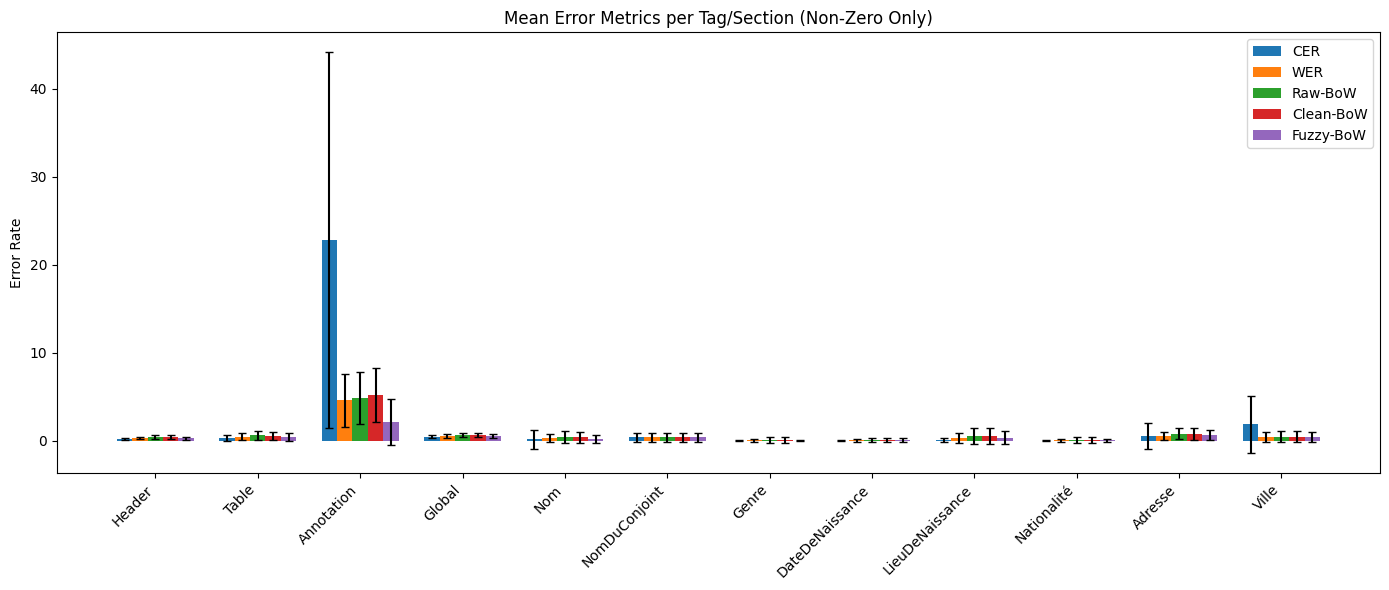


📊 Summary of Issues:
🔸 Total missing prediction files: 3
🔸 Total malformed XML files: 16


In [23]:
# --- Main ---
gt_root = "GTs"
pred_root = "../../data/Qwen7b-2shot"

# Now also retrieving missing and malformed counters
metrics_all, total_missing_predictions, total_malformed_xml = evaluate_all_repos(gt_root, pred_root)

# Merging all tag-level metrics across subdirs
combined_tag_type_metrics = defaultdict(lambda: defaultdict(list))

for subdir_metrics in metrics_all.values():
    tag_type_metrics = subdir_metrics["tag_type_metrics"]
    for tag, metrics in tag_type_metrics.items():
        for metric_key, values in metrics.items():
            combined_tag_type_metrics[tag][metric_key].extend(values)

# Global metrics summary
all_file_metrics = []
for subdir_metrics in metrics_all.values():
    all_file_metrics.extend(subdir_metrics["metrics_per_file"])

print_and_summarize_metrics(all_file_metrics, label="Batch Metrics")

# Section-level summaries
section_keys = {
    "__Header__": "Batch Header",
    "__Table__": "Batch Table",
    "__Annotation__": "Batch Annotation",
}

for internal_key, label in section_keys.items():
    if internal_key in combined_tag_type_metrics:
        section_metrics = combined_tag_type_metrics[internal_key]
        metrics_list = []
        num_values = len(next(iter(section_metrics.values()), []))
        for i in range(num_values):
            metrics_list.append({
                metric: section_metrics[metric][i] for metric in section_metrics
            })
        print_and_summarize_metrics(metrics_list, label=f"{label} Metrics")

# Plot valid non-zero metrics
plot_mean_metrics_by_tag(combined_tag_type_metrics)

# Print summary of errors
print("\n📊 Summary of Issues:")
print(f"🔸 Total missing prediction files: {total_missing_predictions}")
print(f"🔸 Total malformed XML files: {total_malformed_xml}")
